In [1]:
import numpy as np # Math
import pandas as pd # Data tables
import matplotlib.pyplot as plt # Plots
import sklearn # Classic ML

Pruning Alpha: 0.00066
Leaves: 143, Depth: 11
R^2 Score: 0.695
Root Mean Square Error: 0.632
Mean Absolute Error: 0.440


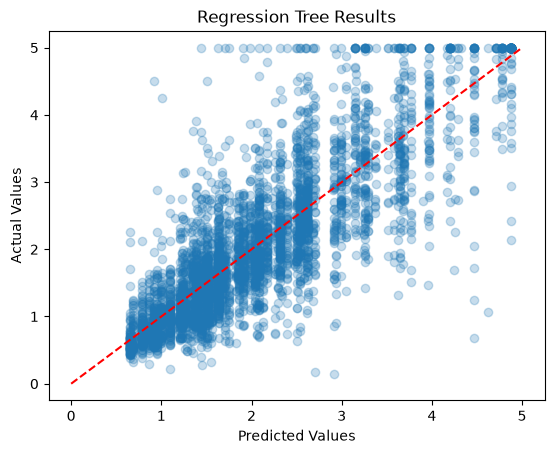

In [2]:
# Scikit-learn: Regression Tree
from sklearn.tree import DecisionTreeRegressor
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error

N_SPLITS = 5

def one_se(cv_results):
    """Index of the largest alpha within 1 SE of the best CV score."""
    mean = cv_results["mean_test_score"]
    se = cv_results["std_test_score"]/np.sqrt(N_SPLITS) # get the SE's for the CV results
    best = mean.argmax() # index of cv with best mean score
    alphas = np.array(cv_results["param_ccp_alpha"], dtype=float)
    allowable = np.where(mean >= mean[best] - se[best])[0] # indexes of results within 1 SE
    return allowable[alphas[allowable].argmax()] # return index of largest alpha withint 1 SE of highest mean 


database = fetch_california_housing(as_frame=True).frame
X = database.drop(columns="MedHouseVal")
y = database["MedHouseVal"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

path = DecisionTreeRegressor(random_state=42).cost_complexity_pruning_path(X_train, y_train)
alphas = path.ccp_alphas[:-1]
grid = np.geomspace(alphas[alphas > 0].min(), alphas.max(), 250)

search = GridSearchCV(DecisionTreeRegressor(random_state=42),
                      cv=KFold(n_splits=N_SPLITS, shuffle=True, random_state=42),
                      param_grid={"ccp_alpha": grid},
                      refit=one_se,
                      n_jobs=-1).fit(X_train, y_train)


RT_model = search.best_estimator_
predictions = RT_model.predict(X_test)
print(f"Pruning Alpha: {RT_model.ccp_alpha:.5f}") # top scoring alpha within 1 SE
print(f"Leaves: {RT_model.get_n_leaves()}, Depth: {RT_model.get_depth()}")
print(f"R^2 Score: {RT_model.score(X_test,y_test):.3f}")
print(f"Root Mean Square Error: {mean_squared_error(y_test, predictions) ** 0.5:.3f}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, predictions):.3f}")

plt.scatter(predictions, y_test, alpha=0.25)
plt.plot([0, 5], [0, 5], "r--")
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.title('Regression Tree Results')
plt.show()
